# evNew2 recreate from CSV

Place these files in the same folder as this notebook before running:
- `hybrid_figure_data.csv`
- `hybrid_metrics_scaled.csv`

This notebook restores the original variable names and recreates the figures/tables using the same plot formatting as the original notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ---------- load saved outputs ----------
figure_df = pd.read_csv('hybrid_figure_data.csv')
metrics_df_loaded = pd.read_csv('hybrid_metrics_scaled.csv', index_col=0)

# ---------- restore original variables ----------
# Use SCALED columns to match the original evNew2 notebook behavior
actual = figure_df['actual_scaled'].to_numpy()
final_pso = figure_df['sarima_pso_tcn_scaled'].to_numpy()
final_ga = figure_df['sarima_ga_tcn_scaled'].to_numpy()
sarima_pred = figure_df['sarima_forecast_scaled'].to_numpy()
res_pso = figure_df['pso_residual_pred_scaled'].to_numpy()
res_ga = figure_df['ga_residual_pred_scaled'].to_numpy()

residual_pso = actual - final_pso
residual_ga = actual - final_ga

# Match original variable usage
window = 0

# Rebuild original metric tuples in the same order as evaluate() returned them
metrics_pso = tuple(metrics_df_loaded.loc['SARIMA-PSO-TCN', ['MAE', 'RMSE', 'SMAPE', 'R2']].tolist())
metrics_ga = tuple(metrics_df_loaded.loc['SARIMA-GA-TCN', ['MAE', 'RMSE', 'SMAPE', 'R2']].tolist())

# Also rebuild metrics_df in the same format as the original table cell
metrics_df = pd.DataFrame({
    'Model': ['SARIMA-PSO-TCN', 'SARIMA-GA-TCN'],
    'MAE': [metrics_pso[0], metrics_ga[0]],
    'RMSE': [metrics_pso[1], metrics_ga[1]],
    'SMAPE': [metrics_pso[2], metrics_ga[2]],
    'R2': [metrics_pso[3], metrics_ga[3]]
})

print('Loaded evNew2 figure and metric data successfully.')
print(metrics_df)


Loaded evNew2 figure and metric data successfully.
            Model       MAE      RMSE      SMAPE        R2
0  SARIMA-PSO-TCN  0.040523  0.056740  29.741414  0.880495
1   SARIMA-GA-TCN  0.042508  0.058709  30.722297  0.872058


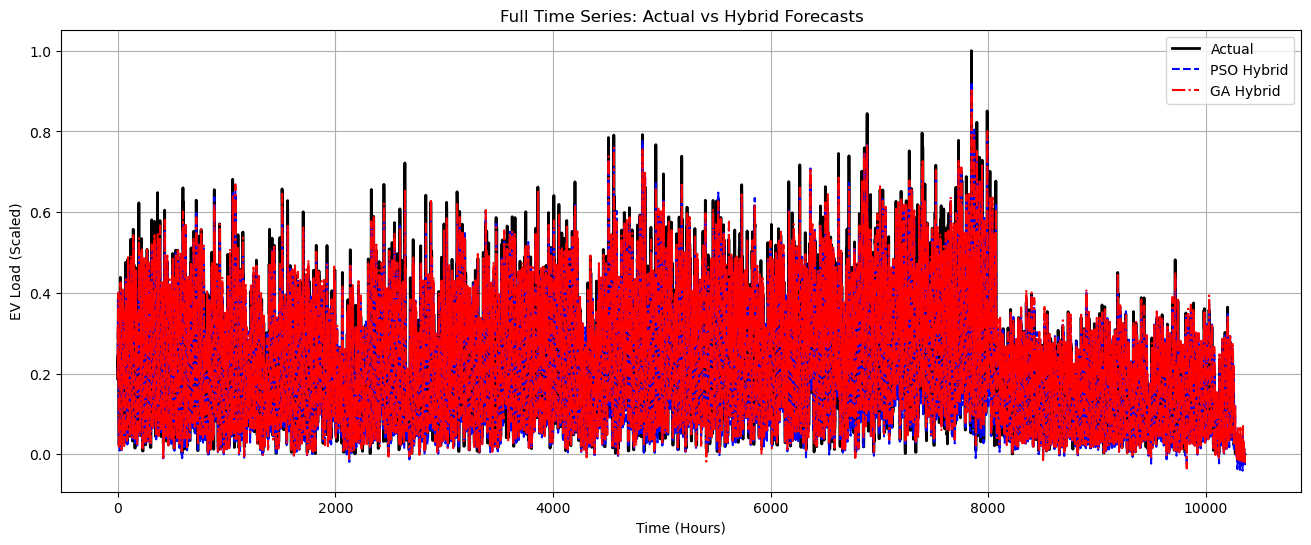

In [21]:
plt.figure(figsize=(16,6))
plt.plot(actual, label='Actual', color='black', linewidth=2)
plt.plot(final_pso, label='PSO Hybrid', color='blue', linestyle='--')
plt.plot(final_ga, label='GA Hybrid', color='red', linestyle='-.')
plt.title('Full Time Series: Actual vs Hybrid Forecasts')
plt.xlabel('Time (Hours)')
plt.ylabel('EV Load (Scaled)')
plt.legend()
plt.grid(True)
plt.show()


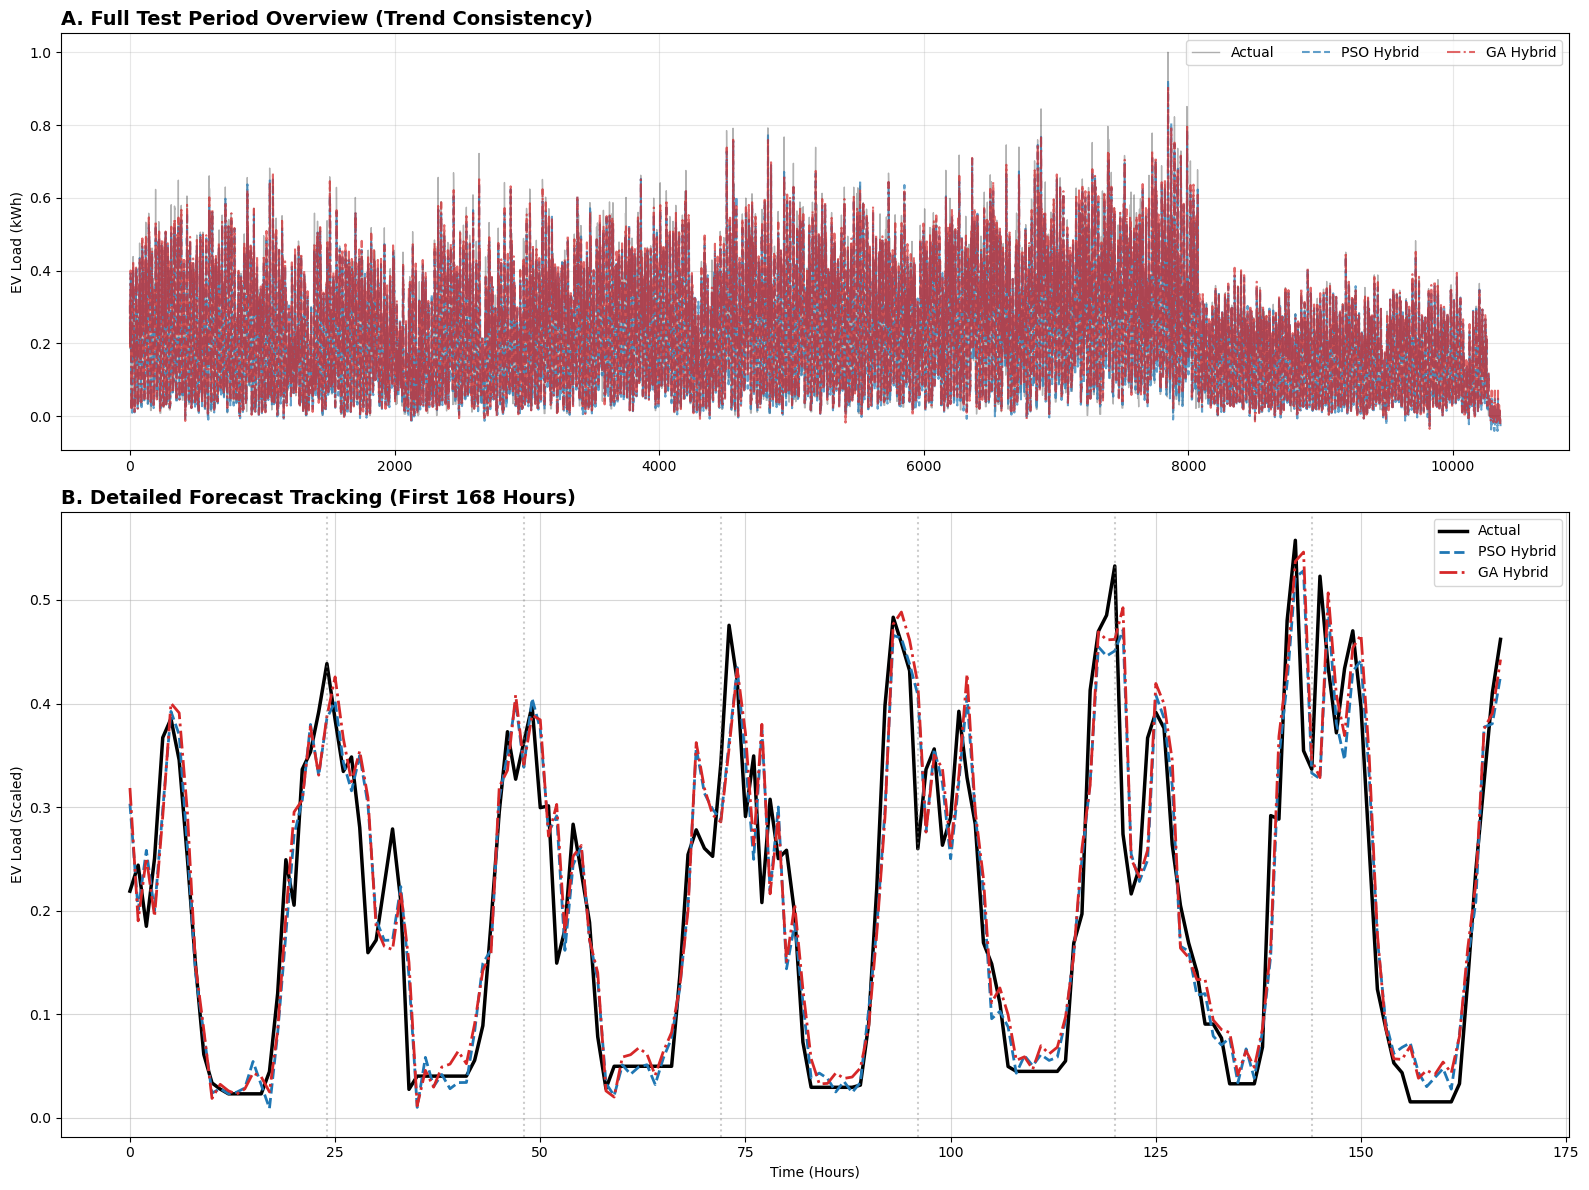

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1.5]})

ax1.plot(actual, label='Actual', color='black', alpha=0.3, linewidth=1)
ax1.plot(final_pso, label='PSO Hybrid', color='#1f77b4', alpha=0.7, linestyle='--')
ax1.plot(final_ga, label='GA Hybrid', color='#d62728', alpha=0.7, linestyle='-.')
ax1.set_title('A. Full Test Period Overview (Trend Consistency)', loc='left', fontsize=14, fontweight='bold')
ax1.set_ylabel('EV Load (kWh)')
ax1.legend(loc='upper right', ncol=3)
ax1.grid(True, alpha=0.3)

zoom_range = 168  # One week of hourly data
ax2.plot(actual[:zoom_range], label='Actual', color='black', linewidth=2.5)
ax2.plot(final_pso[:zoom_range], label='PSO Hybrid', color='#1f77b4', linewidth=2, linestyle='--')
ax2.plot(final_ga[:zoom_range], label='GA Hybrid', color='#d62728', linewidth=2, linestyle='-.')

ax2.set_title(f'B. Detailed Forecast Tracking (First {zoom_range} Hours)', loc='left', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (Hours)')
ax2.set_ylabel('EV Load (Scaled)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax2.axvline(x=i, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


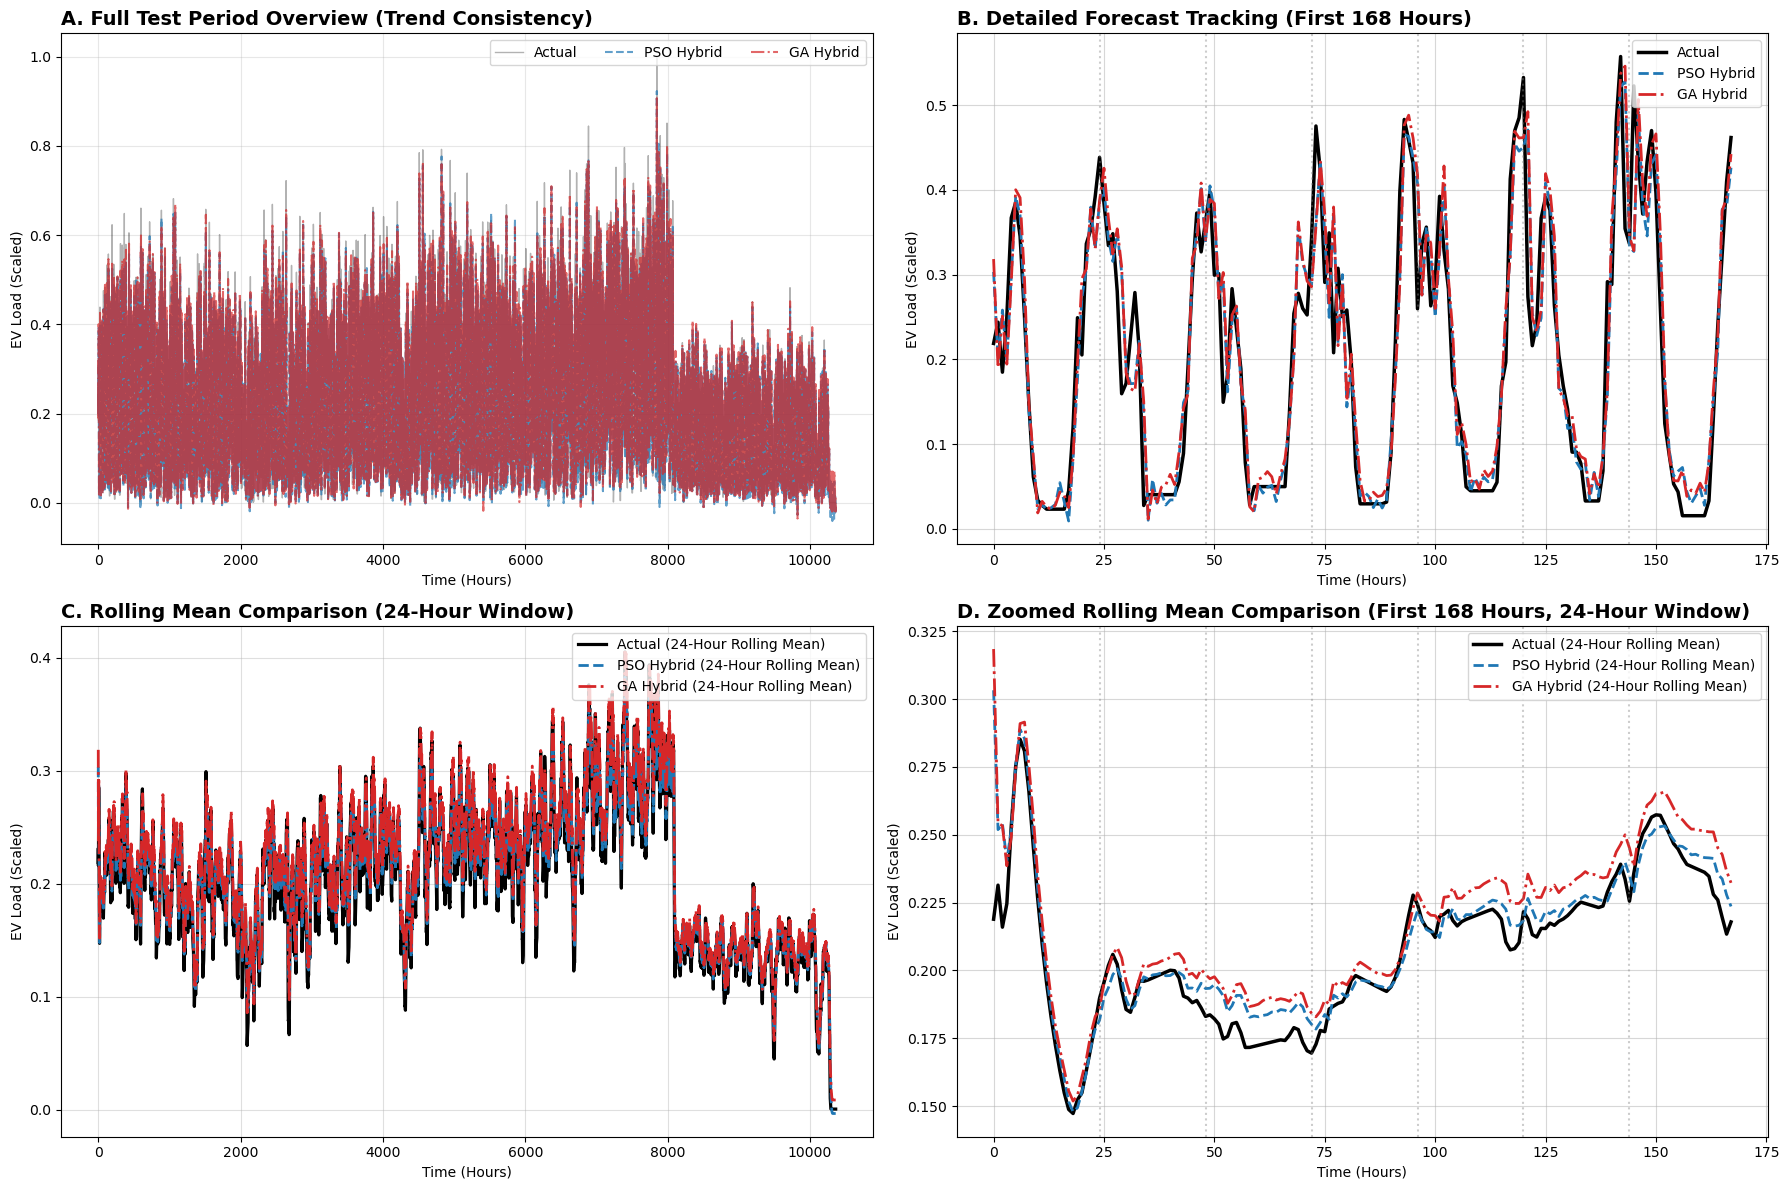

In [23]:
# ============================================================
# ROLLING MEAN COMPARISON — same 2x2 arrangement as revised notebook
# ============================================================

# Convert to 1D arrays just to be safe
actual_plot = np.asarray(actual).reshape(-1)
pso_plot = np.asarray(final_pso).reshape(-1)
ga_plot = np.asarray(final_ga).reshape(-1)

zoom_range = 168       # One week of hourly data
rolling_window = 24    # 24-hour rolling mean

# Rolling means
actual_roll = pd.Series(actual_plot).rolling(window=rolling_window, min_periods=1).mean()
pso_roll = pd.Series(pso_plot).rolling(window=rolling_window, min_periods=1).mean()
ga_roll = pd.Series(ga_plot).rolling(window=rolling_window, min_periods=1).mean()

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

ax1, ax2, ax3, ax4 = axes.flatten()

# A. Full test period overview
ax1.plot(actual_plot, label='Actual', color='black', alpha=0.3, linewidth=1)
ax1.plot(pso_plot, label='PSO Hybrid', color='#1f77b4', alpha=0.7, linestyle='--')
ax1.plot(ga_plot, label='GA Hybrid', color='#d62728', alpha=0.7, linestyle='-.')

ax1.set_title("A. Full Test Period Overview (Trend Consistency)", loc='left', fontsize=14, fontweight='bold')
ax1.set_xlabel("Time (Hours)")
ax1.set_ylabel("EV Load (Scaled)")
ax1.legend(loc='upper right', ncol=3)
ax1.grid(True, alpha=0.3)

# B. Detailed forecast tracking
ax2.plot(actual_plot[:zoom_range], label='Actual', color='black', linewidth=2.5)
ax2.plot(pso_plot[:zoom_range], label='PSO Hybrid', color='#1f77b4', linewidth=2, linestyle='--')
ax2.plot(ga_plot[:zoom_range], label='GA Hybrid', color='#d62728', linewidth=2, linestyle='-.')

ax2.set_title(f"B. Detailed Forecast Tracking (First {zoom_range} Hours)", loc='left', fontsize=14, fontweight='bold')
ax2.set_xlabel("Time (Hours)")
ax2.set_ylabel("EV Load (Scaled)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax2.axvline(x=i, color='gray', linestyle=':', alpha=0.4)

# C. Rolling mean comparison
ax3.plot(actual_roll, label=f'Actual ({rolling_window}-Hour Rolling Mean)', color='black', linewidth=2.3)
ax3.plot(pso_roll, label=f'PSO Hybrid ({rolling_window}-Hour Rolling Mean)', color='#1f77b4', linewidth=2, linestyle='--')
ax3.plot(ga_roll, label=f'GA Hybrid ({rolling_window}-Hour Rolling Mean)', color='#d62728', linewidth=2, linestyle='-.')

ax3.set_title(f"C. Rolling Mean Comparison ({rolling_window}-Hour Window)", loc='left', fontsize=14, fontweight='bold')
ax3.set_xlabel("Time (Hours)")
ax3.set_ylabel("EV Load (Scaled)")
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.4)

# D. Zoomed rolling mean comparison
ax4.plot(actual_roll[:zoom_range], label=f'Actual ({rolling_window}-Hour Rolling Mean)', color='black', linewidth=2.5)
ax4.plot(pso_roll[:zoom_range], label=f'PSO Hybrid ({rolling_window}-Hour Rolling Mean)', color='#1f77b4', linewidth=2, linestyle='--')
ax4.plot(ga_roll[:zoom_range], label=f'GA Hybrid ({rolling_window}-Hour Rolling Mean)', color='#d62728', linewidth=2, linestyle='-.')

ax4.set_title(
    f"D. Zoomed Rolling Mean Comparison (First {zoom_range} Hours, {rolling_window}-Hour Window)",
    loc='left',
    fontsize=14,
    fontweight='bold'
)

ax4.set_xlabel("Time (Hours)")
ax4.set_ylabel("EV Load (Scaled)")
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax4.axvline(x=i, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

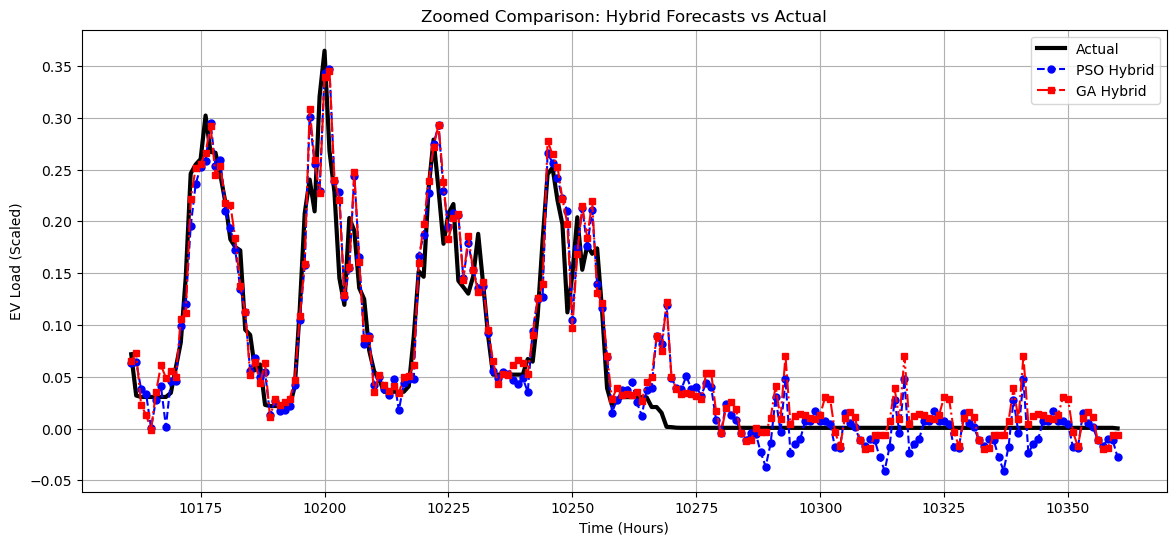

In [24]:
zoom_points = 200
x_zoom = range(len(actual)-zoom_points, len(actual))

plt.figure(figsize=(14,6))
plt.plot(x_zoom, actual[-zoom_points:], label='Actual', color='black', linewidth=3)
plt.plot(x_zoom, final_pso[-zoom_points:], label='PSO Hybrid', color='blue', linestyle='--', marker='o', markersize=5)
plt.plot(x_zoom, final_ga[-zoom_points:], label='GA Hybrid', color='red', linestyle='-.', marker='s', markersize=5)
plt.title('Zoomed Comparison: Hybrid Forecasts vs Actual')
plt.xlabel('Time (Hours)')
plt.ylabel('EV Load (Scaled)')
plt.legend()
plt.grid(True)
plt.show()


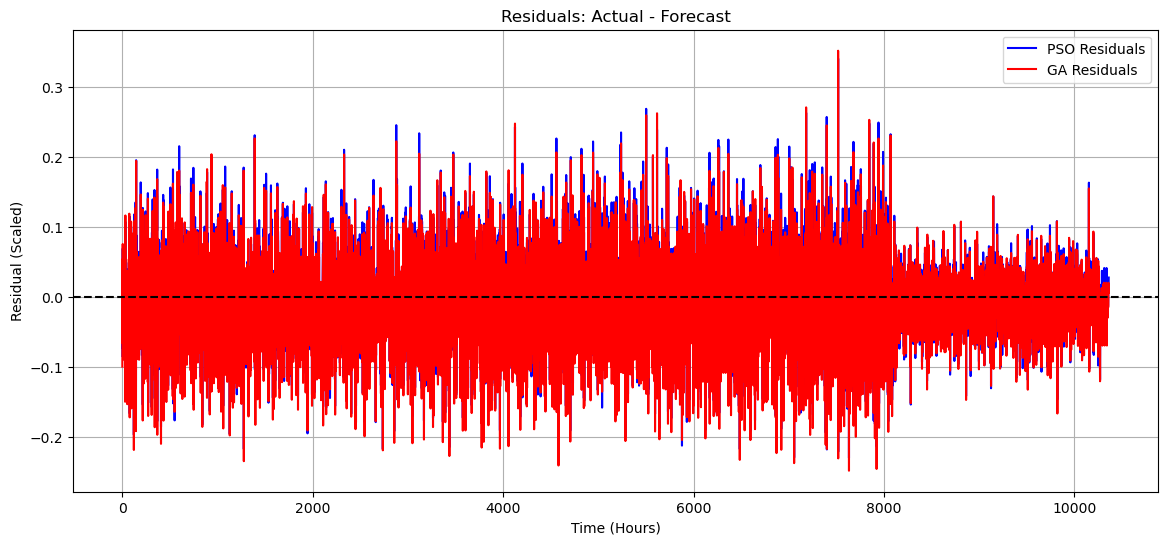

In [25]:
residual_pso = actual - final_pso
residual_ga = actual - final_ga

plt.figure(figsize=(14,6))
plt.plot(residual_pso, label='PSO Residuals', color='blue')
plt.plot(residual_ga, label='GA Residuals', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals: Actual - Forecast')
plt.xlabel('Time (Hours)')
plt.ylabel('Residual (Scaled)')
plt.legend()
plt.grid(True)
plt.show()


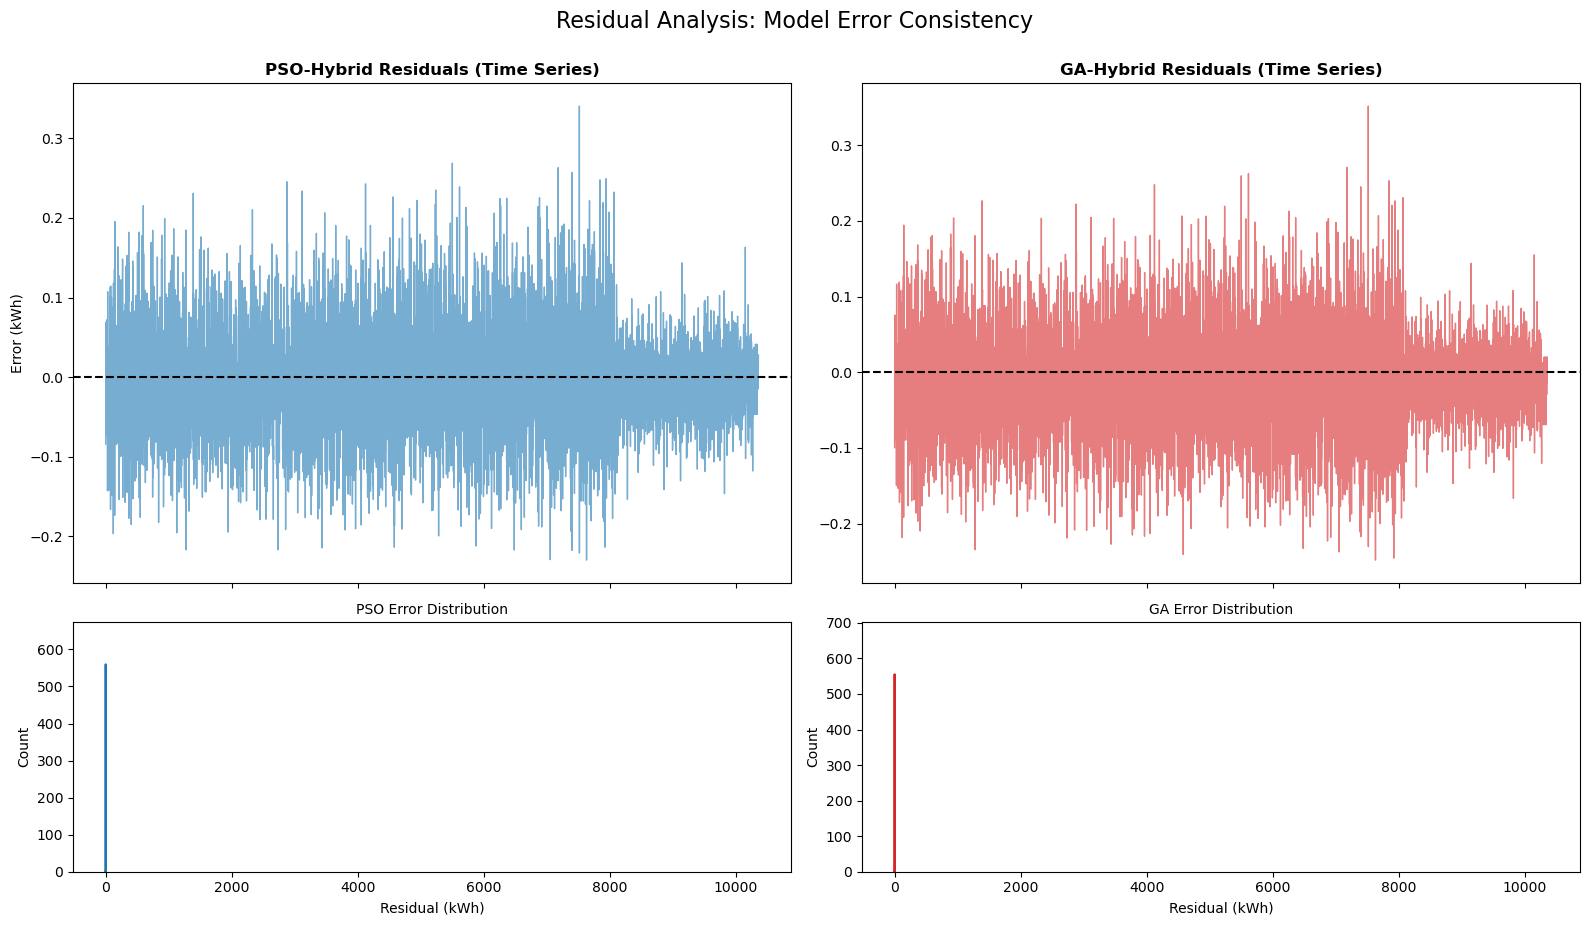

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [2, 1]})

# --- PSO RESIDUALS (Left Column) ---
axes[0, 0].plot(residual_pso, color='#1f77b4', alpha=0.6, linewidth=1)
axes[0, 0].set_title('PSO-Hybrid Residuals (Time Series)', fontsize=12, fontweight='bold')
axes[0, 0].axhline(0, color='black', lw=1.5, ls='--')
axes[0, 0].set_ylabel('Error (kWh)')

sns.histplot(residual_pso, kde=True, ax=axes[1, 0], color='#1f77b4')
axes[1, 0].set_title('PSO Error Distribution', fontsize=10)
axes[1, 0].set_xlabel('Residual (kWh)')

# --- GA RESIDUALS (Right Column) ---
axes[0, 1].plot(residual_ga, color='#d62728', alpha=0.6, linewidth=1)
axes[0, 1].set_title('GA-Hybrid Residuals (Time Series)', fontsize=12, fontweight='bold')
axes[0, 1].axhline(0, color='black', lw=1.5, ls='--')

sns.histplot(residual_ga, kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('GA Error Distribution', fontsize=10)
axes[1, 1].set_xlabel('Residual (kWh)')

plt.suptitle('Residual Analysis: Model Error Consistency', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


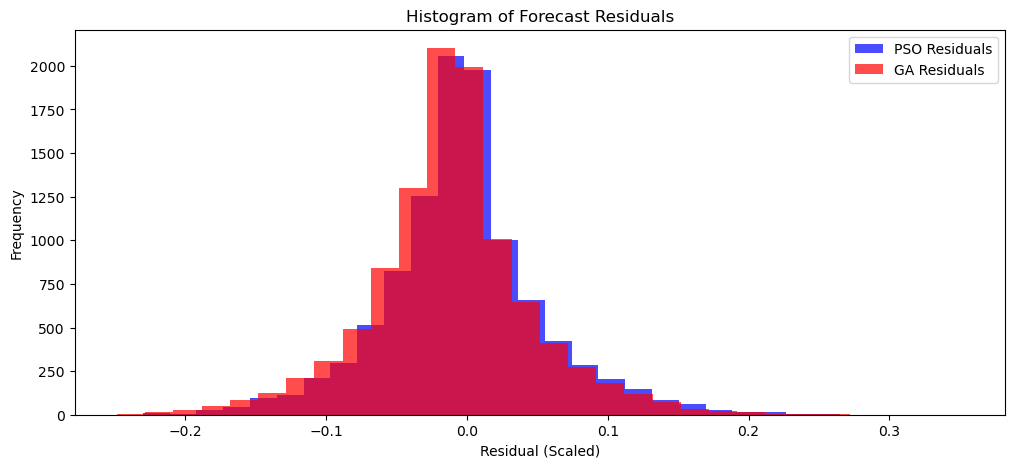

In [26]:
plt.figure(figsize=(12,5))
plt.hist(residual_pso, bins=30, alpha=0.7, label='PSO Residuals', color='blue')
plt.hist(residual_ga, bins=30, alpha=0.7, label='GA Residuals', color='red')
plt.title('Histogram of Forecast Residuals')
plt.xlabel('Residual (Scaled)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


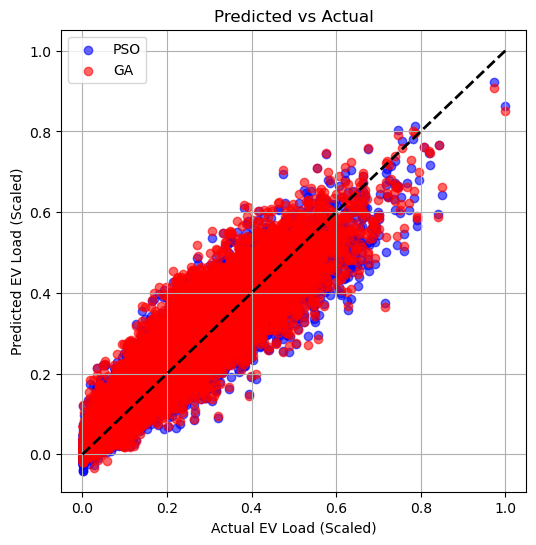

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(actual, final_pso, label='PSO', color='blue', alpha=0.6)
plt.scatter(actual, final_ga, label='GA', color='red', alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'k--', lw=2)
plt.xlabel('Actual EV Load (Scaled)')
plt.ylabel('Predicted EV Load (Scaled)')
plt.title('Predicted vs Actual')
plt.legend()
plt.grid(True)
plt.show()


            Model       MAE      RMSE      SMAPE        R2
0  SARIMA-PSO-TCN  0.040523  0.056740  29.741414  0.880495
1   SARIMA-GA-TCN  0.042508  0.058709  30.722297  0.872058


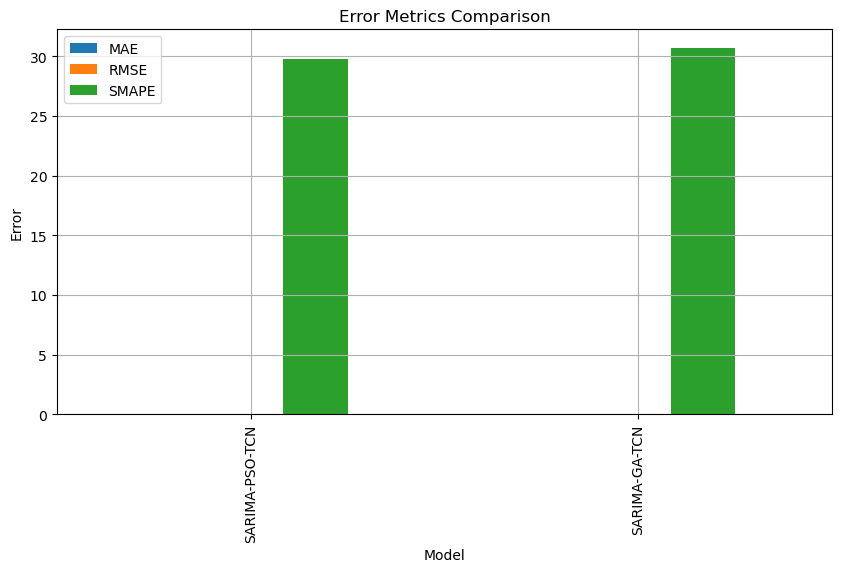

In [10]:
metrics_df = pd.DataFrame({
    'Model': ['SARIMA-PSO-TCN', 'SARIMA-GA-TCN'],
    'MAE': [metrics_pso[0], metrics_ga[0]],
    'RMSE': [metrics_pso[1], metrics_ga[1]],
    'SMAPE': [metrics_pso[2], metrics_ga[2]],
    'R2': [metrics_pso[3], metrics_ga[3]]
})
print(metrics_df)

metrics_df.set_index('Model')[['MAE','RMSE','SMAPE']].plot(kind='bar', figsize=(10,5))
plt.title('Error Metrics Comparison')
plt.ylabel('Error')
plt.grid(True)
plt.show()


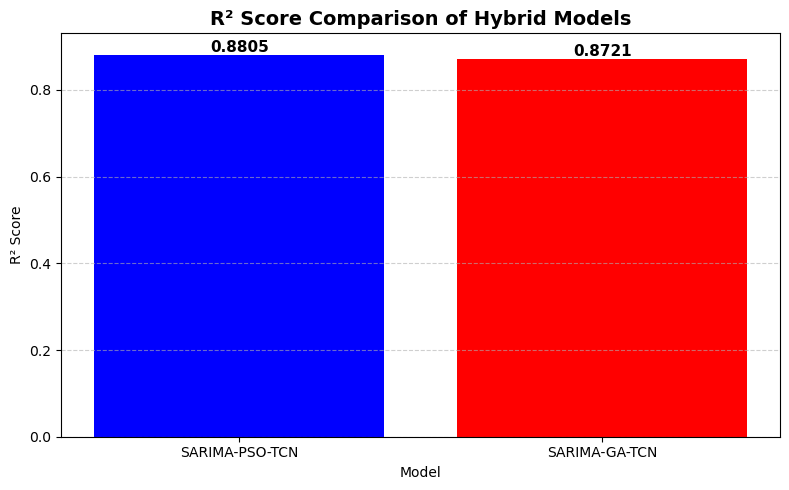

In [11]:
# ============================================================
# R² COMPARISON FIGURE
# Place this after the Error Metrics Comparison figure
# ============================================================

import matplotlib.pyplot as plt

# Make sure R2 values are numeric
metrics_df["R2"] = pd.to_numeric(metrics_df["R2"], errors="coerce")

# Sort models by R² score from highest to lowest
r2_df = metrics_df[["Model", "R2"]].sort_values("R2", ascending=False)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    r2_df["Model"],
    r2_df["R2"],
    color=["blue", "red"]
)

plt.title("R² Score Comparison of Hybrid Models", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Adjust y-axis depending on values
min_r2 = r2_df["R2"].min()
max_r2 = r2_df["R2"].max()

if min_r2 >= 0:
    plt.ylim(0, min(1.05, max_r2 + 0.05))
else:
    plt.axhline(0, color="black", linewidth=1)
    plt.ylim(min_r2 - 0.05, max_r2 + 0.05)

plt.tight_layout()
plt.show()

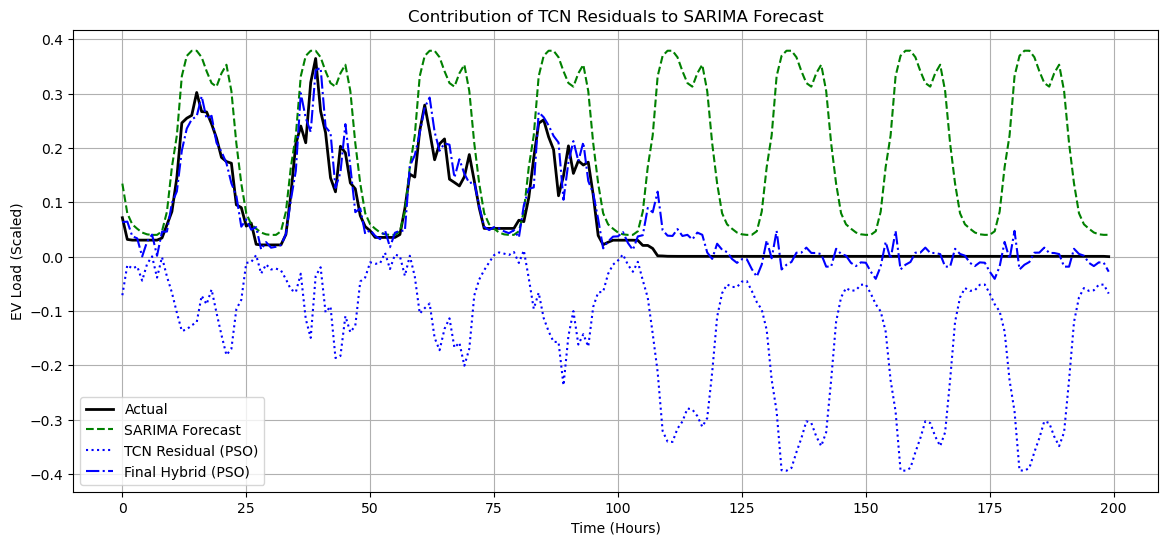

In [28]:
zoom_points = 200
plt.figure(figsize=(14,6))
plt.plot(actual[-zoom_points:], label='Actual', color='black', linewidth=2)
plt.plot(sarima_pred[window:][-zoom_points:], label='SARIMA Forecast', color='green', linestyle='--')
plt.plot(res_pso[-zoom_points:], label='TCN Residual (PSO)', color='blue', linestyle=':')
plt.plot(final_pso[-zoom_points:], label='Final Hybrid (PSO)', color='blue', linestyle='-.')
plt.title('Contribution of TCN Residuals to SARIMA Forecast')
plt.xlabel('Time (Hours)')
plt.ylabel('EV Load (Scaled)')
plt.legend()
plt.grid(True)
plt.show()


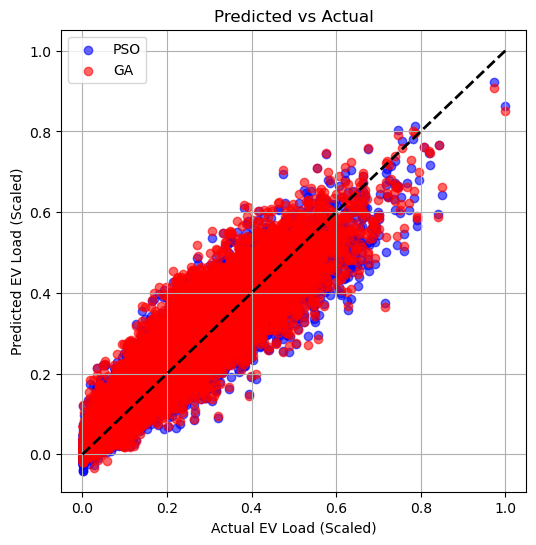

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(actual, final_pso, label='PSO', color='blue', alpha=0.6)
plt.scatter(actual, final_ga, label='GA', color='red', alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'k--', lw=2)
plt.xlabel('Actual EV Load (Scaled)')
plt.ylabel('Predicted EV Load (Scaled)')
plt.title('Predicted vs Actual')
plt.legend()
plt.grid(True)
plt.show()

Corrected kWh Metrics


,Model,MAE,RMSE,SMAPE,R2
0,SARIMA-PSO-TCN,9.111051,12.757257,29.741414,0.880495
1,SARIMA-GA-TCN,9.557350,13.199932,30.722297,0.872058


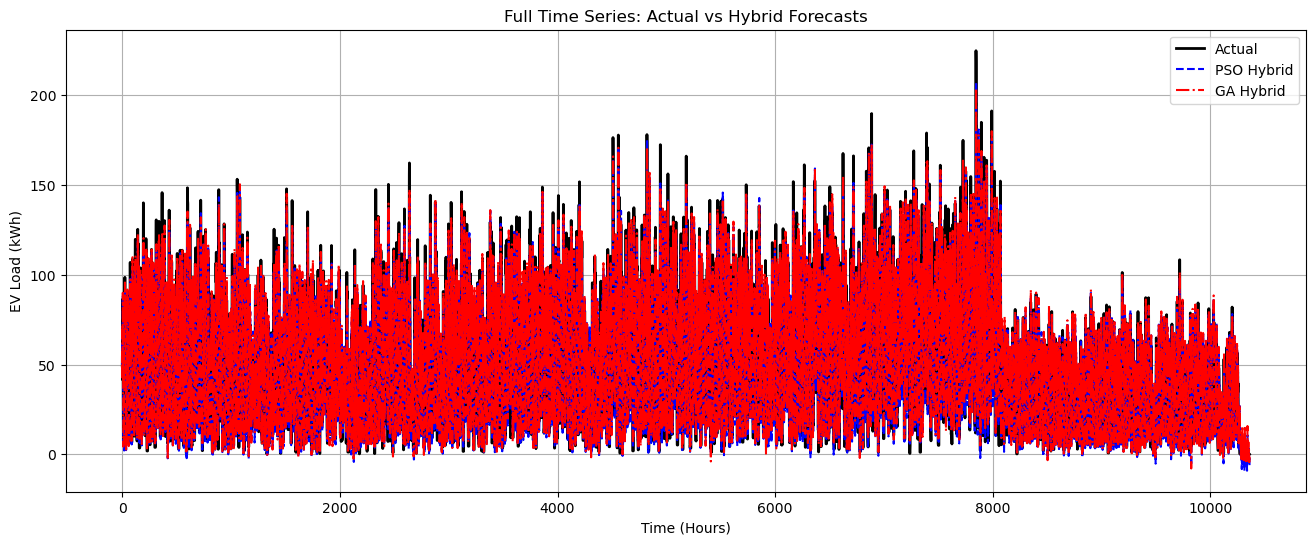

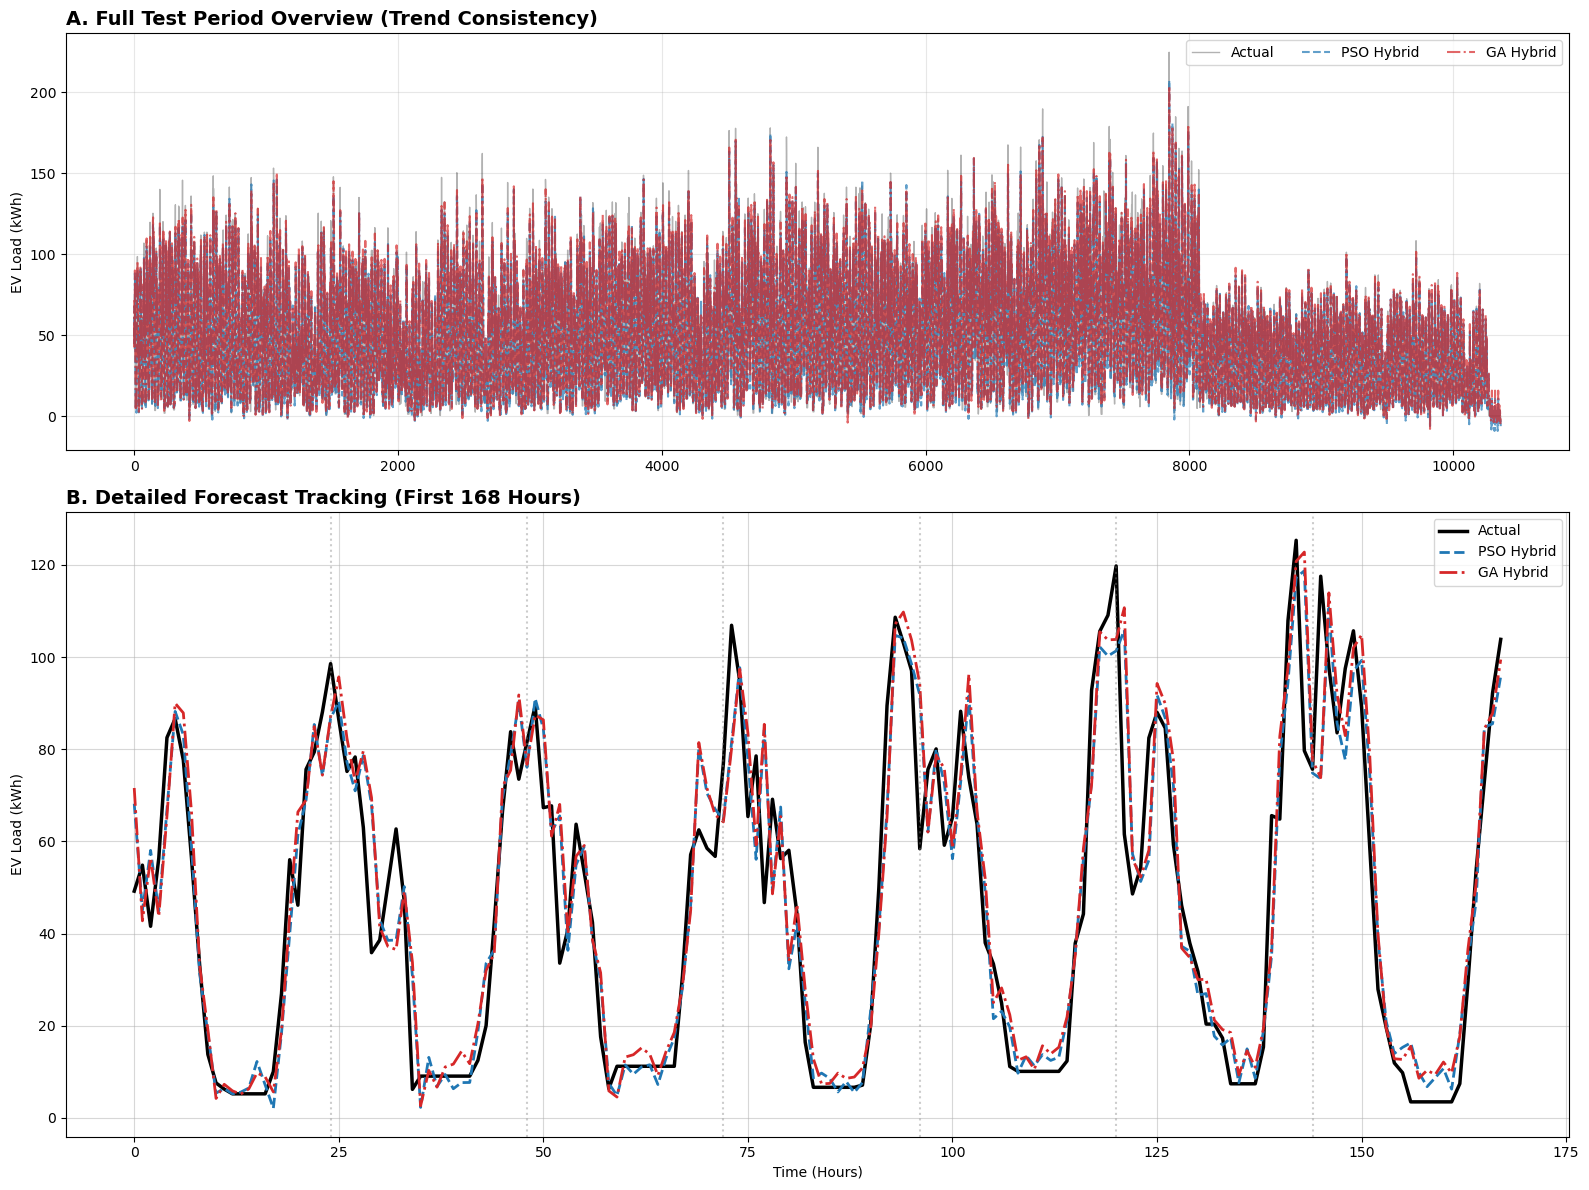

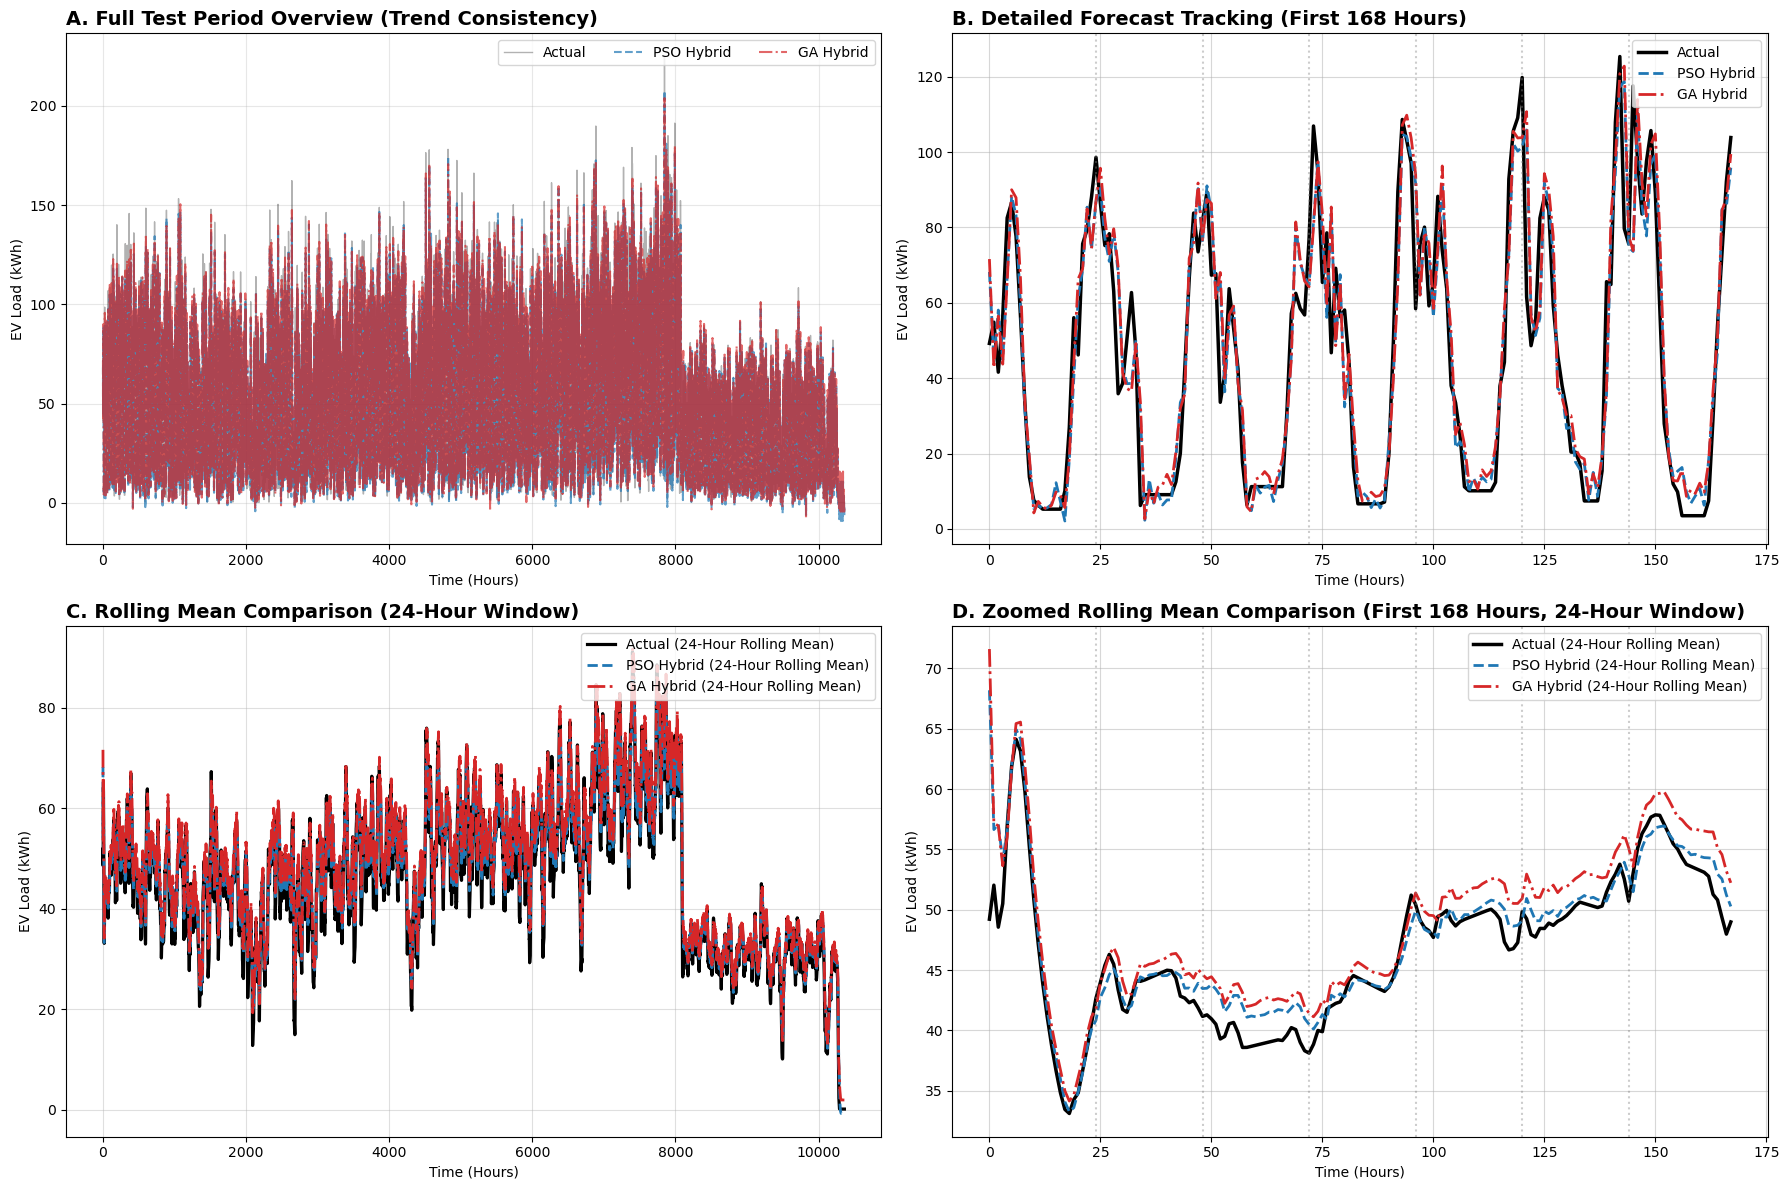

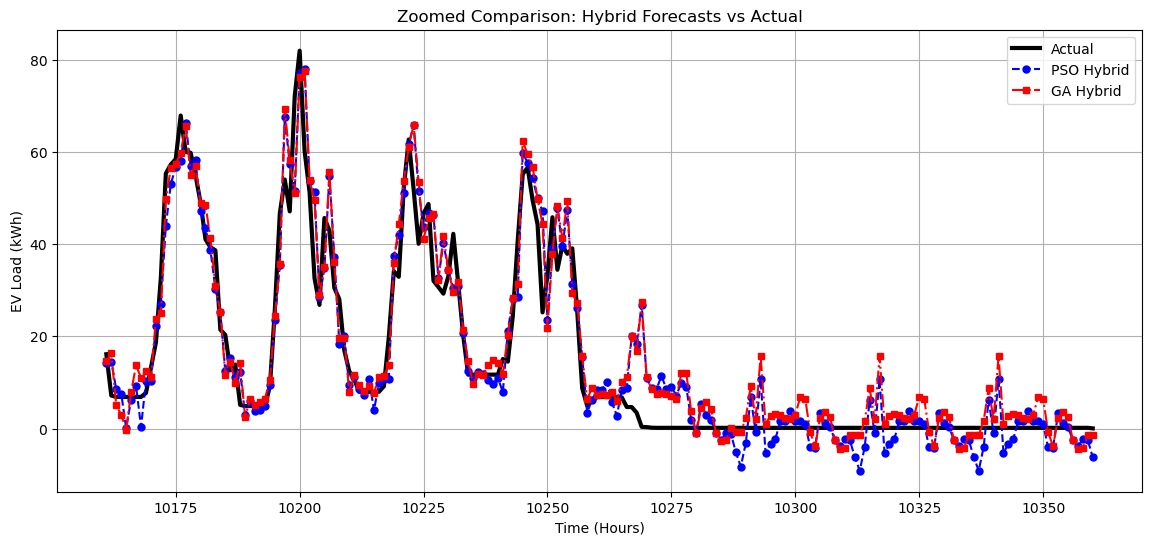

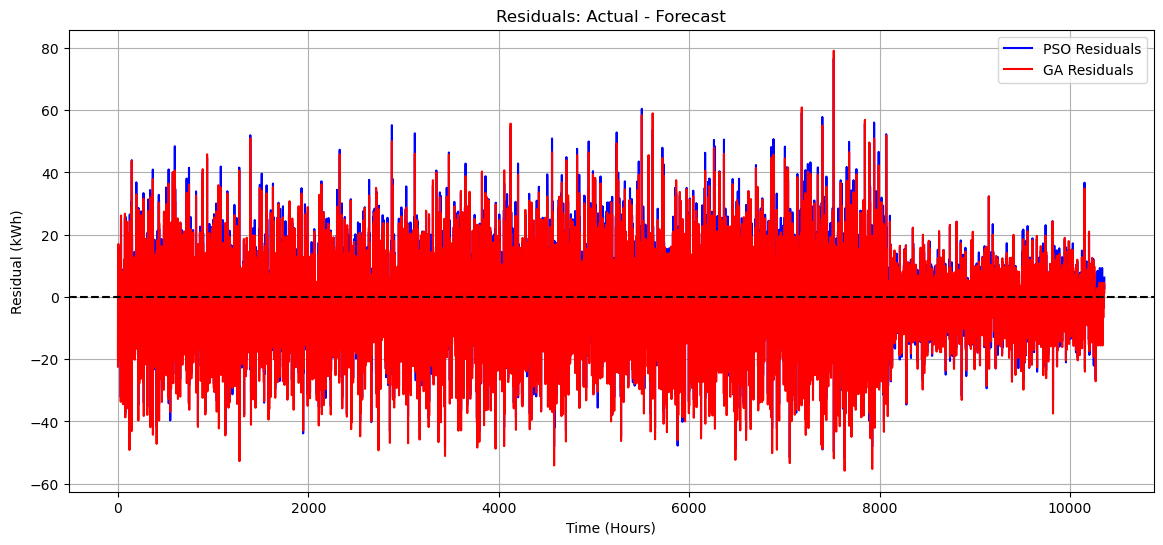

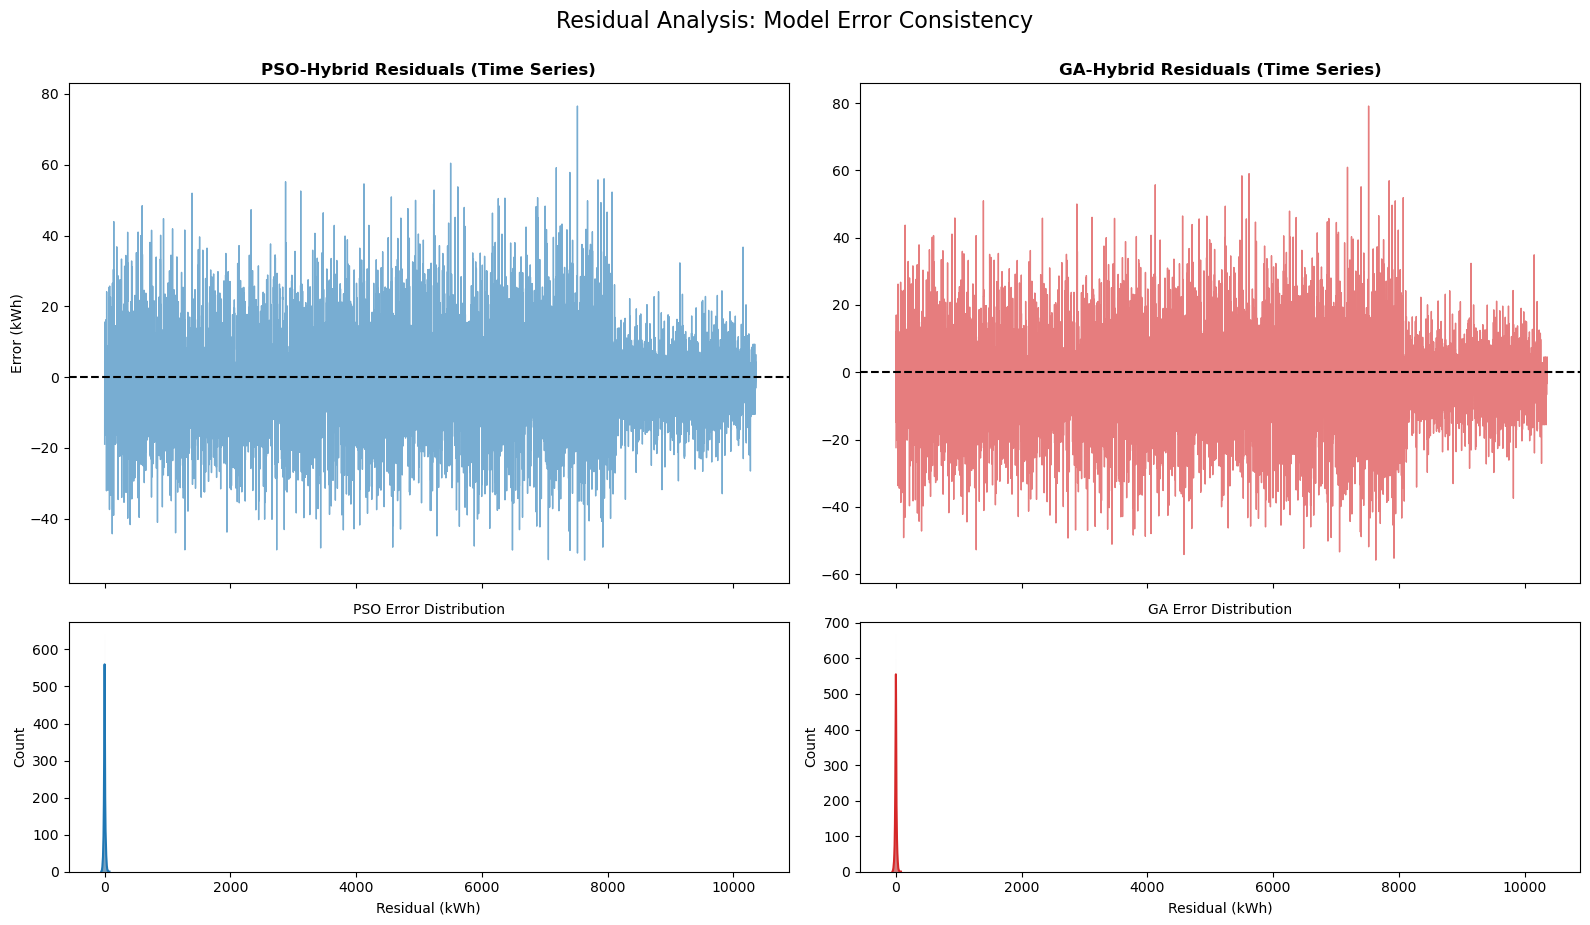

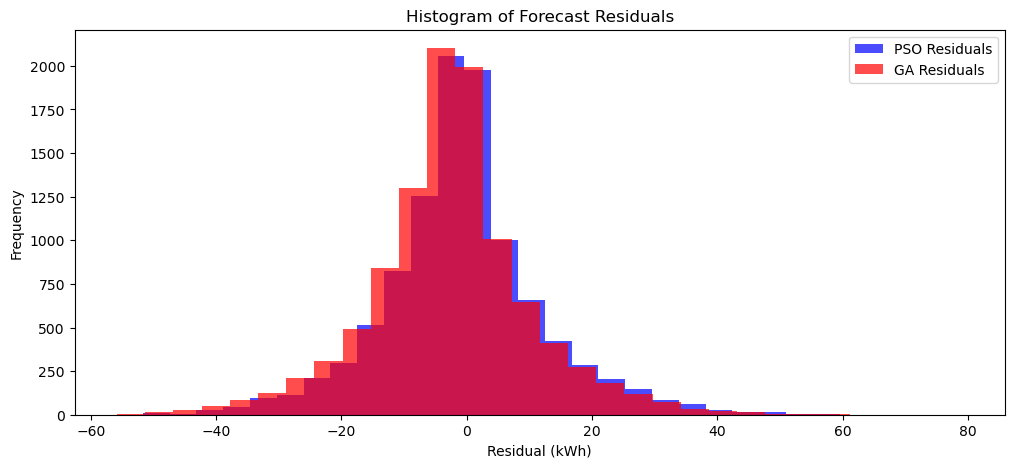

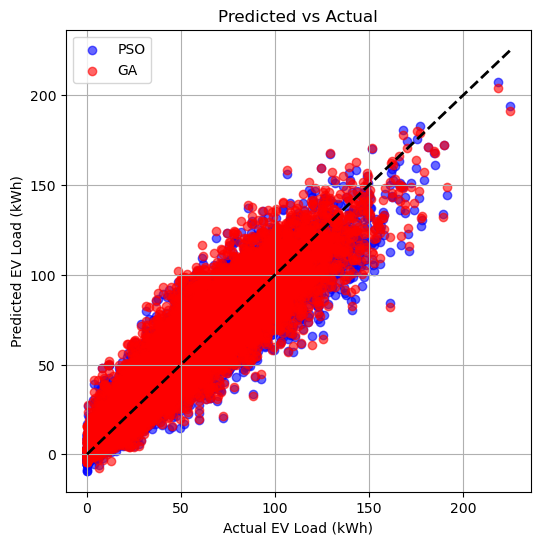

            Model       MAE       RMSE      SMAPE        R2
0  SARIMA-PSO-TCN  9.111051  12.757257  29.741414  0.880495
1   SARIMA-GA-TCN  9.557350  13.199932  30.722297  0.872058


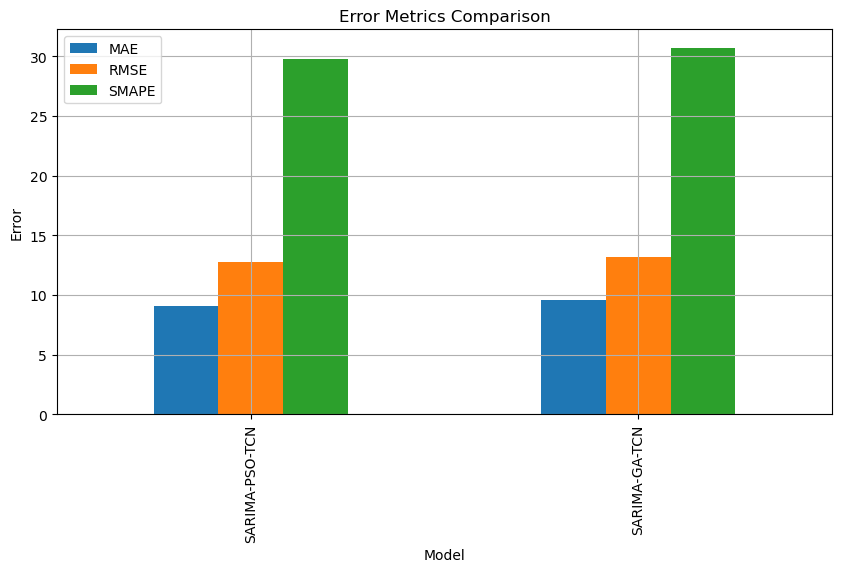

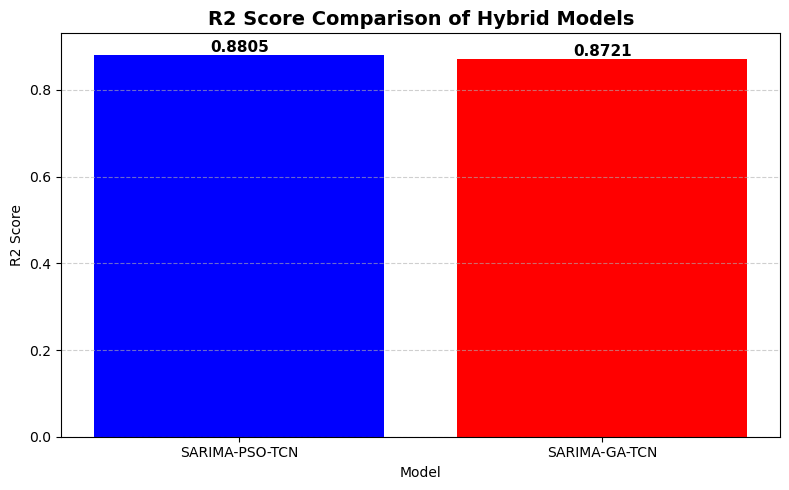

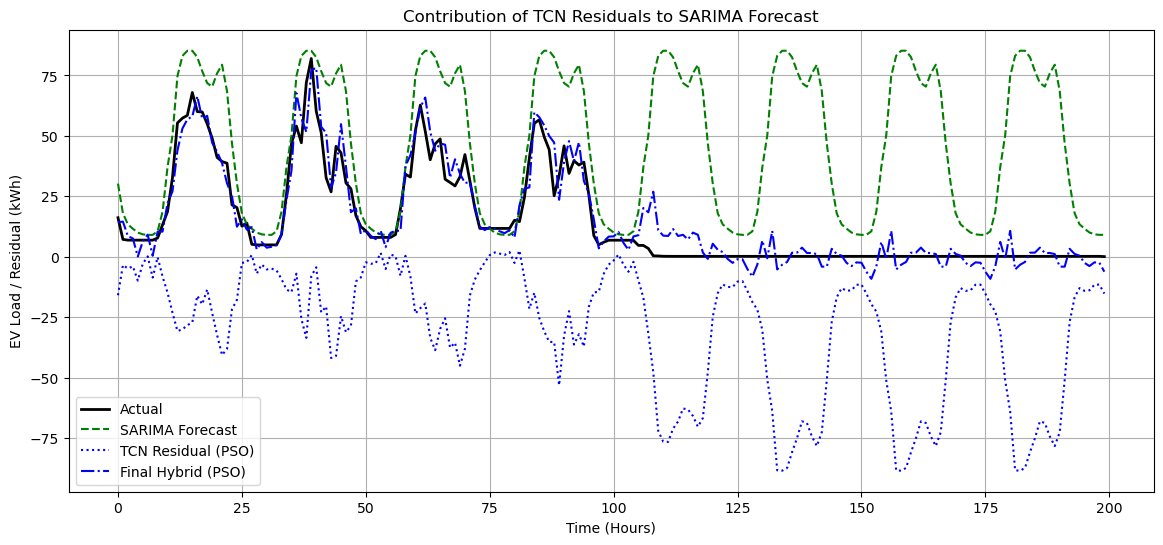

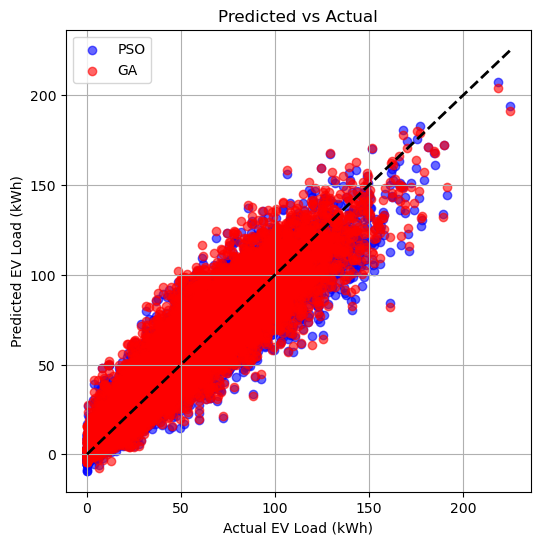

In [19]:
# ============================================================
# RECREATE ALL ORIGINAL GRAPHS USING CORRECTED kWh SCALE
# Same colors/styles as original recreate notebook
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def _flat(x):
    return np.asarray(x).reshape(-1)

def smape(y_true, y_pred):
    y_true = _flat(y_true)
    y_pred = _flat(y_pred)

    denominator = np.abs(y_true) + np.abs(y_pred)
    denominator = np.where(denominator == 0, 1e-12, denominator)

    return 100 / len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / denominator
    )

def inverse_if_needed(values, scaler):
    values = np.asarray(values).reshape(-1, 1)
    return scaler.inverse_transform(values).reshape(-1)

# ------------------------------------------------------------
# Locate exported files
# ------------------------------------------------------------
possible_figure_paths = [
    Path("hybrid_figure_data.csv"),
    Path("evNew2_exports/hybrid_figure_data.csv")
]

possible_metrics_paths = [
    Path("hybrid_metrics_kwh.csv"),
    Path("evNew2_exports/hybrid_metrics_kwh.csv")
]

figure_path = next((p for p in possible_figure_paths if p.exists()), None)
metrics_kwh_path = next((p for p in possible_metrics_paths if p.exists()), None)

if figure_path is None:
    raise FileNotFoundError(
        "Could not find hybrid_figure_data.csv. "
        "Place it in the notebook folder or inside evNew2_exports/."
    )

figure_df = pd.read_csv(figure_path)

# ------------------------------------------------------------
# Load corrected kWh values
# ------------------------------------------------------------
required_kwh_cols = [
    "actual_kwh",
    "sarima_forecast_kwh",
    "sarima_pso_tcn_kwh",
    "sarima_ga_tcn_kwh"
]

if all(col in figure_df.columns for col in required_kwh_cols):
    actual_kwh = figure_df["actual_kwh"].to_numpy()
    sarima_kwh = figure_df["sarima_forecast_kwh"].to_numpy()
    final_pso_kwh = figure_df["sarima_pso_tcn_kwh"].to_numpy()
    final_ga_kwh = figure_df["sarima_ga_tcn_kwh"].to_numpy()

else:
    required_scaled_cols = [
        "actual_scaled",
        "sarima_forecast_scaled",
        "sarima_pso_tcn_scaled",
        "sarima_ga_tcn_scaled"
    ]

    if not all(col in figure_df.columns for col in required_scaled_cols):
        raise ValueError(
            "The figure CSV does not contain the required kWh or scaled columns."
        )

    if "scaler" not in globals():
        raise NameError(
            "The CSV only has scaled values, but no fitted scaler variable was found. "
            "Run the earlier notebook cells first, or export the kWh columns from the revised notebook."
        )

    actual_kwh = inverse_if_needed(figure_df["actual_scaled"], scaler)
    sarima_kwh = inverse_if_needed(figure_df["sarima_forecast_scaled"], scaler)
    final_pso_kwh = inverse_if_needed(figure_df["sarima_pso_tcn_scaled"], scaler)
    final_ga_kwh = inverse_if_needed(figure_df["sarima_ga_tcn_scaled"], scaler)

# ------------------------------------------------------------
# Correct kWh residuals/errors
# ------------------------------------------------------------
residual_pso_kwh = actual_kwh - final_pso_kwh
residual_ga_kwh = actual_kwh - final_ga_kwh

# TCN residual/correction contribution in kWh
if "pso_residual_pred_kwh" in figure_df.columns:
    res_pso_kwh = figure_df["pso_residual_pred_kwh"].to_numpy()
else:
    res_pso_kwh = final_pso_kwh - sarima_kwh

if "ga_residual_pred_kwh" in figure_df.columns:
    res_ga_kwh = figure_df["ga_residual_pred_kwh"].to_numpy()
else:
    res_ga_kwh = final_ga_kwh - sarima_kwh

window = 0

# ------------------------------------------------------------
# Correct kWh metrics
# ------------------------------------------------------------
if metrics_kwh_path is not None:
    metrics_df_loaded = pd.read_csv(metrics_kwh_path, index_col=0)

    metrics_pso = tuple(
        metrics_df_loaded.loc[
            "SARIMA-PSO-TCN",
            ["MAE", "RMSE", "SMAPE", "R2"]
        ].tolist()
    )

    metrics_ga = tuple(
        metrics_df_loaded.loc[
            "SARIMA-GA-TCN",
            ["MAE", "RMSE", "SMAPE", "R2"]
        ].tolist()
    )

else:
    metrics_pso = (
        mean_absolute_error(actual_kwh, final_pso_kwh),
        np.sqrt(mean_squared_error(actual_kwh, final_pso_kwh)),
        smape(actual_kwh, final_pso_kwh),
        r2_score(actual_kwh, final_pso_kwh)
    )

    metrics_ga = (
        mean_absolute_error(actual_kwh, final_ga_kwh),
        np.sqrt(mean_squared_error(actual_kwh, final_ga_kwh)),
        smape(actual_kwh, final_ga_kwh),
        r2_score(actual_kwh, final_ga_kwh)
    )

metrics_df_kwh = pd.DataFrame({
    "Model": ["SARIMA-PSO-TCN", "SARIMA-GA-TCN"],
    "MAE": [metrics_pso[0], metrics_ga[0]],
    "RMSE": [metrics_pso[1], metrics_ga[1]],
    "SMAPE": [metrics_pso[2], metrics_ga[2]],
    "R2": [metrics_pso[3], metrics_ga[3]]
})

print("Corrected kWh Metrics")
display(metrics_df_kwh)

# ============================================================
# 1. Full Time Series: Actual vs Hybrid Forecasts
# ============================================================

plt.figure(figsize=(16, 6))
plt.plot(actual_kwh, label="Actual", color="black", linewidth=2)
plt.plot(final_pso_kwh, label="PSO Hybrid", color="blue", linestyle="--")
plt.plot(final_ga_kwh, label="GA Hybrid", color="red", linestyle="-.")
plt.title("Full Time Series: Actual vs Hybrid Forecasts")
plt.xlabel("Time (Hours)")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 2. Full Overview + Detailed Forecast Tracking
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(16, 12),
    gridspec_kw={"height_ratios": [1, 1.5]}
)

ax1.plot(actual_kwh, label="Actual", color="black", alpha=0.3, linewidth=1)
ax1.plot(final_pso_kwh, label="PSO Hybrid", color="#1f77b4", alpha=0.7, linestyle="--")
ax1.plot(final_ga_kwh, label="GA Hybrid", color="#d62728", alpha=0.7, linestyle="-.")
ax1.set_title("A. Full Test Period Overview (Trend Consistency)", loc="left", fontsize=14, fontweight="bold")
ax1.set_ylabel("EV Load (kWh)")
ax1.legend(loc="upper right", ncol=3)
ax1.grid(True, alpha=0.3)

zoom_range = min(168, len(actual_kwh))

ax2.plot(actual_kwh[:zoom_range], label="Actual", color="black", linewidth=2.5)
ax2.plot(final_pso_kwh[:zoom_range], label="PSO Hybrid", color="#1f77b4", linewidth=2, linestyle="--")
ax2.plot(final_ga_kwh[:zoom_range], label="GA Hybrid", color="#d62728", linewidth=2, linestyle="-.")

ax2.set_title(f"B. Detailed Forecast Tracking (First {zoom_range} Hours)", loc="left", fontsize=14, fontweight="bold")
ax2.set_xlabel("Time (Hours)")
ax2.set_ylabel("EV Load (kWh)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax2.axvline(x=i, color="gray", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# 3. Rolling Mean Comparison, same 2x2 arrangement
# ============================================================

actual_plot = np.asarray(actual_kwh).reshape(-1)
pso_plot = np.asarray(final_pso_kwh).reshape(-1)
ga_plot = np.asarray(final_ga_kwh).reshape(-1)

rolling_window = 24

actual_roll = pd.Series(actual_plot).rolling(window=rolling_window, min_periods=1).mean()
pso_roll = pd.Series(pso_plot).rolling(window=rolling_window, min_periods=1).mean()
ga_roll = pd.Series(ga_plot).rolling(window=rolling_window, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.plot(actual_plot, label="Actual", color="black", alpha=0.3, linewidth=1)
ax1.plot(pso_plot, label="PSO Hybrid", color="#1f77b4", alpha=0.7, linestyle="--")
ax1.plot(ga_plot, label="GA Hybrid", color="#d62728", alpha=0.7, linestyle="-.")

ax1.set_title("A. Full Test Period Overview (Trend Consistency)", loc="left", fontsize=14, fontweight="bold")
ax1.set_xlabel("Time (Hours)")
ax1.set_ylabel("EV Load (kWh)")
ax1.legend(loc="upper right", ncol=3)
ax1.grid(True, alpha=0.3)

ax2.plot(actual_plot[:zoom_range], label="Actual", color="black", linewidth=2.5)
ax2.plot(pso_plot[:zoom_range], label="PSO Hybrid", color="#1f77b4", linewidth=2, linestyle="--")
ax2.plot(ga_plot[:zoom_range], label="GA Hybrid", color="#d62728", linewidth=2, linestyle="-.")

ax2.set_title(f"B. Detailed Forecast Tracking (First {zoom_range} Hours)", loc="left", fontsize=14, fontweight="bold")
ax2.set_xlabel("Time (Hours)")
ax2.set_ylabel("EV Load (kWh)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax2.axvline(x=i, color="gray", linestyle=":", alpha=0.4)

ax3.plot(actual_roll, label=f"Actual ({rolling_window}-Hour Rolling Mean)", color="black", linewidth=2.3)
ax3.plot(pso_roll, label=f"PSO Hybrid ({rolling_window}-Hour Rolling Mean)", color="#1f77b4", linewidth=2, linestyle="--")
ax3.plot(ga_roll, label=f"GA Hybrid ({rolling_window}-Hour Rolling Mean)", color="#d62728", linewidth=2, linestyle="-.")

ax3.set_title(f"C. Rolling Mean Comparison ({rolling_window}-Hour Window)", loc="left", fontsize=14, fontweight="bold")
ax3.set_xlabel("Time (Hours)")
ax3.set_ylabel("EV Load (kWh)")
ax3.legend(loc="upper right")
ax3.grid(True, alpha=0.4)

ax4.plot(actual_roll[:zoom_range], label=f"Actual ({rolling_window}-Hour Rolling Mean)", color="black", linewidth=2.5)
ax4.plot(pso_roll[:zoom_range], label=f"PSO Hybrid ({rolling_window}-Hour Rolling Mean)", color="#1f77b4", linewidth=2, linestyle="--")
ax4.plot(ga_roll[:zoom_range], label=f"GA Hybrid ({rolling_window}-Hour Rolling Mean)", color="#d62728", linewidth=2, linestyle="-.")

ax4.set_title(
    f"D. Zoomed Rolling Mean Comparison (First {zoom_range} Hours, {rolling_window}-Hour Window)",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Time (Hours)")
ax4.set_ylabel("EV Load (kWh)")
ax4.legend(loc="upper right")
ax4.grid(True, alpha=0.5)

for i in range(24, zoom_range, 24):
    ax4.axvline(x=i, color="gray", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Zoomed Comparison: Hybrid Forecasts vs Actual
# ============================================================

zoom_points = min(200, len(actual_kwh))
x_zoom = range(len(actual_kwh) - zoom_points, len(actual_kwh))

plt.figure(figsize=(14, 6))
plt.plot(x_zoom, actual_kwh[-zoom_points:], label="Actual", color="black", linewidth=3)
plt.plot(x_zoom, final_pso_kwh[-zoom_points:], label="PSO Hybrid", color="blue", linestyle="--", marker="o", markersize=5)
plt.plot(x_zoom, final_ga_kwh[-zoom_points:], label="GA Hybrid", color="red", linestyle="-.", marker="s", markersize=5)
plt.title("Zoomed Comparison: Hybrid Forecasts vs Actual")
plt.xlabel("Time (Hours)")
plt.ylabel("EV Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 5. Residuals: Actual - Forecast
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(residual_pso_kwh, label="PSO Residuals", color="blue")
plt.plot(residual_ga_kwh, label="GA Residuals", color="red")
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals: Actual - Forecast")
plt.xlabel("Time (Hours)")
plt.ylabel("Residual (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 6. Residual Analysis: Time Series + Distribution
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex="col",
    gridspec_kw={"height_ratios": [2, 1]}
)

axes[0, 0].plot(residual_pso_kwh, color="#1f77b4", alpha=0.6, linewidth=1)
axes[0, 0].set_title("PSO-Hybrid Residuals (Time Series)", fontsize=12, fontweight="bold")
axes[0, 0].axhline(0, color="black", lw=1.5, ls="--")
axes[0, 0].set_ylabel("Error (kWh)")

sns.histplot(residual_pso_kwh, kde=True, ax=axes[1, 0], color="#1f77b4")
axes[1, 0].set_title("PSO Error Distribution", fontsize=10)
axes[1, 0].set_xlabel("Residual (kWh)")

axes[0, 1].plot(residual_ga_kwh, color="#d62728", alpha=0.6, linewidth=1)
axes[0, 1].set_title("GA-Hybrid Residuals (Time Series)", fontsize=12, fontweight="bold")
axes[0, 1].axhline(0, color="black", lw=1.5, ls="--")

sns.histplot(residual_ga_kwh, kde=True, ax=axes[1, 1], color="#d62728")
axes[1, 1].set_title("GA Error Distribution", fontsize=10)
axes[1, 1].set_xlabel("Residual (kWh)")

plt.suptitle("Residual Analysis: Model Error Consistency", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 7. Histogram of Forecast Residuals
# ============================================================

plt.figure(figsize=(12, 5))
plt.hist(residual_pso_kwh, bins=30, alpha=0.7, label="PSO Residuals", color="blue")
plt.hist(residual_ga_kwh, bins=30, alpha=0.7, label="GA Residuals", color="red")
plt.title("Histogram of Forecast Residuals")
plt.xlabel("Residual (kWh)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# ============================================================
# 8. Predicted vs Actual
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(actual_kwh, final_pso_kwh, label="PSO", color="blue", alpha=0.6)
plt.scatter(actual_kwh, final_ga_kwh, label="GA", color="red", alpha=0.6)
plt.plot([actual_kwh.min(), actual_kwh.max()], [actual_kwh.min(), actual_kwh.max()], "k--", lw=2)
plt.xlabel("Actual EV Load (kWh)")
plt.ylabel("Predicted EV Load (kWh)")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 9. Error Metrics Comparison using corrected kWh metrics
# ============================================================

print(metrics_df_kwh)

metrics_df_kwh.set_index("Model")[["MAE", "RMSE", "SMAPE"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Error Metrics Comparison")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ============================================================
# 10. R2 Score Comparison
# ============================================================

metrics_df_kwh["R2"] = pd.to_numeric(metrics_df_kwh["R2"], errors="coerce")
r2_df = metrics_df_kwh[["Model", "R2"]].sort_values("R2", ascending=False)

r2_color_map = {
    "SARIMA-PSO-TCN": "blue",
    "SARIMA-GA-TCN": "red"
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    r2_df["Model"],
    r2_df["R2"],
    color=[r2_color_map[m] for m in r2_df["Model"]]
)

plt.title("R2 Score Comparison of Hybrid Models", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

min_r2 = r2_df["R2"].min()
max_r2 = r2_df["R2"].max()

if min_r2 >= 0:
    plt.ylim(0, min(1.05, max_r2 + 0.05))
else:
    plt.axhline(0, color="black", linewidth=1)
    plt.ylim(min_r2 - 0.05, max_r2 + 0.05)

plt.tight_layout()
plt.show()

# ============================================================
# 11. Contribution of TCN Residuals to SARIMA Forecast
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(actual_kwh[-zoom_points:], label="Actual", color="black", linewidth=2)
plt.plot(sarima_kwh[window:][-zoom_points:], label="SARIMA Forecast", color="green", linestyle="--")
plt.plot(res_pso_kwh[-zoom_points:], label="TCN Residual (PSO)", color="blue", linestyle=":")
plt.plot(final_pso_kwh[-zoom_points:], label="Final Hybrid (PSO)", color="blue", linestyle="-.")
plt.title("Contribution of TCN Residuals to SARIMA Forecast")
plt.xlabel("Time (Hours)")
plt.ylabel("EV Load / Residual (kWh)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 12. Final duplicate Predicted vs Actual, matching original notebook
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(actual_kwh, final_pso_kwh, label="PSO", color="blue", alpha=0.6)
plt.scatter(actual_kwh, final_ga_kwh, label="GA", color="red", alpha=0.6)
plt.plot([actual_kwh.min(), actual_kwh.max()], [actual_kwh.min(), actual_kwh.max()], "k--", lw=2)
plt.xlabel("Actual EV Load (kWh)")
plt.ylabel("Predicted EV Load (kWh)")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()